## Check if integral of |W| divided by frequency band depends on oscillation frequency

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

import matlab.engine

In [2]:
eng = matlab.engine.start_matlab()

# Two synthetic signals:

$$
s_1 = \cos(2\pi f_1 t) + \epsilon_1,
$$

$$
s_2 = \cos(2\pi f_2 t) + \epsilon_2,
$$

where $f_1=0.02\,$Hz, $f_2=0.04\,$Hz, and $\epsilon_{1,2} \sim N(0, 1)$ (white noise).

In [82]:
T = 4000 # s
dt = 0.5 # s
Fs = 1/dt
nt = int(T/dt)

f1, f2 = 0.1, 0.2 # Hz

t = np.arange(nt)*dt

s1 = sg.cosine(T, f1, sampling_frequency=Fs)[1] + np.random.randn(nt)
s2 = sg.cosine(T, f2, sampling_frequency=Fs)[1] + np.random.randn(nt)

In [83]:
1/T

0.00025

In [84]:
integration_band = slice(0.01, 0.4)

### Compute CWT

In [85]:
w1 = wf.matlab_cwt(eng, s1, Fs, voices_per_octave=24)
w2 = wf.matlab_cwt(eng, s2, Fs, voices_per_octave=24)

## Show time-averaged $|W|$ against $f$ 

Text(0.5, 1.0, 'Spectra from cosines with white noise')

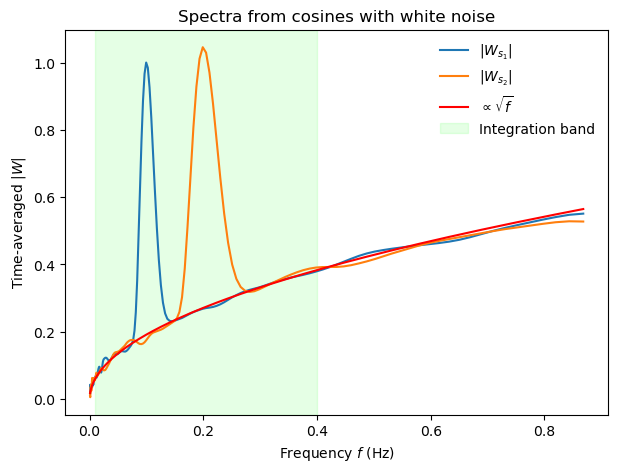

In [86]:
f, ax = plt.subplots(figsize=(7,5))

ax.plot(w1.f, w1.wt_amp.mean('t'), label='$|W_{s_1}|$')
ax.plot(w2.f, w2.wt_amp.mean('t'), label='$|W_{s_2}|$')

ax.plot(w1.f, np.sqrt(w1.f)/1.65, color='r', label=r"$\propto \sqrt{f}$")

ax.set(xlabel='Frequency $f$ (Hz)', ylabel = r'Time-averaged $|W|$')

ax.axvspan(integration_band.start, integration_band.stop, color='lime', alpha=0.1, label='Integration band')
ax.legend(frameon=False)
ax.set_title('Spectra from cosines with white noise')

## Clearly, the integral of $|W_{s_2}|$ (orange) should be larger than that of $|W_{s_1}|$ since the peak is wider at higher frequency (I don't divide by the integration band because it is identical for s1 and s2):

In [87]:
int1 = w1.wt_amp.mean('t')[::-1].sel(f=integration_band).integrate('f') # trapz integration along $f$ inside the integration band
int2 = w2.wt_amp.mean('t')[::-1].sel(f=integration_band).integrate('f') 

In [88]:
print(f"Integral of the 0.1-Hz cosine = {int1.item():.3f}")
print(f"Integral of the 0.2-Hz cosine = {int2.item():.3f}")

Integral of the 0.1-Hz cosine = 0.124
Integral of the 0.2-Hz cosine = 0.143


## The integral of 0.2-Hz cosine is not 2 times higher than that of 0.1-Hz cosine because of the noise. Show this by integrating noiseless cosines:

In [89]:
s1 = sg.cosine(T, f1, sampling_frequency=Fs)[1]
s2 = sg.cosine(T, f2, sampling_frequency=Fs)[1]

In [90]:
w1 = wf.matlab_cwt(eng, s1, Fs, voices_per_octave=24)
w2 = wf.matlab_cwt(eng, s2, Fs, voices_per_octave=24)

Text(0.5, 1.0, 'Spectra from noiseless cosines')

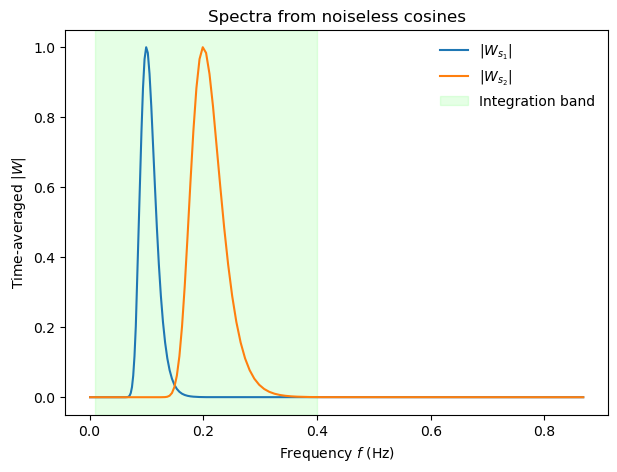

In [91]:
f, ax = plt.subplots(figsize=(7,5))

ax.plot(w1.f, w1.wt_amp.mean('t'), label='$|W_{s_1}|$')
ax.plot(w2.f, w2.wt_amp.mean('t'), label='$|W_{s_2}|$')
ax.set(xlabel='Frequency $f$ (Hz)', ylabel = r'Time-averaged $|W|$')

ax.axvspan(integration_band.start, integration_band.stop, color='lime', alpha=0.1, label='Integration band')
ax.legend(frameon=False)
ax.set_title('Spectra from noiseless cosines')

In [92]:
int1 = w1.wt_amp.mean('t')[::-1].sel(f=integration_band).integrate('f') # trapz integration along $f$ inside the integration band
int2 = w2.wt_amp.mean('t')[::-1].sel(f=integration_band).integrate('f') 

In [93]:
print(f"Integral of the 0.1-Hz cosine = {int1.item():.3f}")
print(f"Integral of the 0.2-Hz cosine = {int2.item():.3f}")

Integral of the 0.1-Hz cosine = 0.034
Integral of the 0.2-Hz cosine = 0.068


## The integral of 0.2-Hz cosine is 2 times higher than that of 0.1-Hz cosine, as it should because (a) CWT was computed with L1 normalization, which preserves the wavelet amplitude (heights of both peaks in the spectrum have nearly the same value=1 (MATLAB normalizes such that it equals oscillation amplitude, which is =1 in our case)); (b) The width of the spectral peaks seen in the plots above grows with frequency $f$ as $\propto f$.

## See also this [notebook](https://github.com/Maliboue/time_freq_lib/blob/main/examples/cwt_via_matlab/cwt_Amplitude_vs_Scale_sumCosines_and_how_to_get_BandIntegratedPower.ipynb) with more examples. E.g. it shows that integral of $|W|^2/f$ doesn't depend on frequency and scales as squared amplitude as power should